# PPC1: Sedimentação de uma esfera com RK4

Este notebook implementa o método de Runge-Kutta de 4ª ordem para resolver o problema de sedimentação de uma esfera em forma adimensional.

#Aluno: Felipe Tavares Loureiro  
#Disciplina: ENM0227 - Cálculo Numérico Aplicado  
#Semestre: 2026.1


## Objetivos

1. Comparar a solução numérica com a solução analítica para diferentes valores de $St$ no caso $Re_s \to 0$.
2. Avaliar o efeito do passo temporal $h$ na qualidade da solução numérica.
3. Resolver numericamente o caso com pequeno efeito inercial.
4. Validar os resultados numéricos com base na solução analítica apresentada no roteiro.
5. Discutir o efeito de $Re_s$ e o desvio em relação ao caso assintótico $Re_s \to 0$.

## Interpretação do limite assintótico $Re_s \to 0$

A forma adimensional mais geral obtida para o problema é

$$
St \frac{dv_z^*}{dt^*} = 1 - v_z^* - \frac{3}{8} Re_s (v_z^*)^2.
$$

Quando $Re_s \to 0$, o termo quadrático desaparece e a equação se reduz a

$$
St \frac{dv_z^*}{dt^*} = 1 - v_z^*.
$$

Esse é o caso assintótico em que o efeito inercial deixa de ser relevante. Para a condição inicial $v_z^*(0)=0$, a solução analítica fica

$$
v_z^*(t^*) = 1 - e^{-t^*/St}.
$$

Essa solução será usada como referência na validação do método numérico nesse regime.

#Imports e definições de funções auxiliares


In [1]:
from math import exp, sqrt
import matplotlib.pyplot as plt


# Convenções usadas no notebook:
# t     : tempo adimensional
# y     : velocidade adimensional
# St    : número de Stokes
# Re_s  : número de Reynolds da partícula
# h     : passo temporal


def funcao(t, y, St, Re_s):
    """
    Equação diferencial adimensional do problema de sedimentação.

    Retorna dy/dt para os valores informados.
    """
    return (1.0 / St) * (1.0 - y - (3.0 / 8.0) * Re_s * y**2)


def rk4(t=0.0, y=0.0, h=0.001, t_final=1.0, St=1.0, Re_s=0.0):
    """
    Resolve a EDO numericamente pelo método de Runge-Kutta de 4ª ordem.

    Retorna duas listas:
    1. tempos calculados
    2. velocidades adimensionais correspondentes
    """
    lista_tempo = [t]
    lista_velocidade = [y]

    while t < t_final - 1e-14:
        h_atual = h

        # Ajusta o último passo para encerrar exatamente em t_final
        if t + h_atual > t_final:
            h_atual = t_final - t

        k1 = funcao(t, y, St, Re_s)
        k2 = funcao(t + 0.5 * h_atual, y + 0.5 * h_atual * k1, St, Re_s)
        k3 = funcao(t + 0.5 * h_atual, y + 0.5 * h_atual * k2, St, Re_s)
        k4 = funcao(t + h_atual, y + h_atual * k3, St, Re_s)

        y = y + (h_atual / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
        t = t + h_atual

        lista_tempo.append(t)
        lista_velocidade.append(y)

    return lista_tempo, lista_velocidade


def solucao_analitica_re_zero(t, St, y0=0.0):
    """
    Solução analítica no caso assintótico Re_s -> 0.
    """
    return 1.0 + (y0 - 1.0) * exp(-t / St)


def velocidade_terminal_caso_inercial(Re_s):
    """
    Calcula a velocidade terminal adimensional no caso com pequeno efeito inercial.
    """
    if abs(Re_s) < 1e-14:
        return 1.0

    return (-1.0 + sqrt(1.0 + 1.5 * Re_s)) / (0.75 * Re_s)


def solucao_analitica_caso_inercial(t, St, Re_s, y0=0.0):
    """
    Solução analítica para o caso com pequeno efeito inercial.
    """
    if abs(Re_s) < 1e-14:
        return solucao_analitica_re_zero(t, St, y0)

    a = (3.0 / 8.0) * Re_s
    raiz = sqrt(1.0 + 4.0 * a)

    y_pos = (-1.0 + raiz) / (2.0 * a)
    y_neg = (-1.0 - raiz) / (2.0 * a)

    constante_inicial = (y0 - y_pos) / (y0 - y_neg)
    fator = exp(-(a / St) * (y_pos - y_neg) * t)
    constante_t = constante_inicial * fator

    return (y_pos - constante_t * y_neg) / (1.0 - constante_t)


def malha_densa(t0, t_final, n_pontos=1000):
    """
    Gera uma malha temporal uniforme para plotar curvas suaves.
    """
    passo = (t_final - t0) / n_pontos
    return [t0 + i * passo for i in range(n_pontos + 1)]


def erro_maximo(tempos, velocidades_numericas, funcao_exata, St, Re_s=None):
    """
    Calcula o maior erro absoluto entre solução numérica e solução analítica.
    """
    erro = 0.0

    for i in range(len(tempos)):
        if Re_s is None:
            valor_exato = funcao_exata(tempos[i], St)
        else:
            valor_exato = funcao_exata(tempos[i], St, Re_s)

        erro_atual = abs(velocidades_numericas[i] - valor_exato)

        if erro_atual > erro:
            erro = erro_atual

    return erro


def mse(valores_numericos, valores_analiticos):
    """
    Calcula o erro médio quadrado entre duas listas de valores.
    """
    if len(valores_numericos) != len(valores_analiticos):
        raise ValueError("As listas devem ter o mesmo tamanho.")

    soma = 0.0
    for yn, ya in zip(valores_numericos, valores_analiticos):
        soma += (yn - ya) ** 2

    return soma / len(valores_numericos)

## Questão 1
(Solução numérica obtida por RK4 comparada com a solução analítica para diferentes valores de $St$, no caso assintótico $Re_s \to 0$.)

        St          erro máximo                  MSE
      0.25     8.1142353947e-09     3.7913140996e-18
      1.00     3.0913049898e-11     2.2009946493e-22
      4.00     1.1635137298e-13     9.5317506729e-27


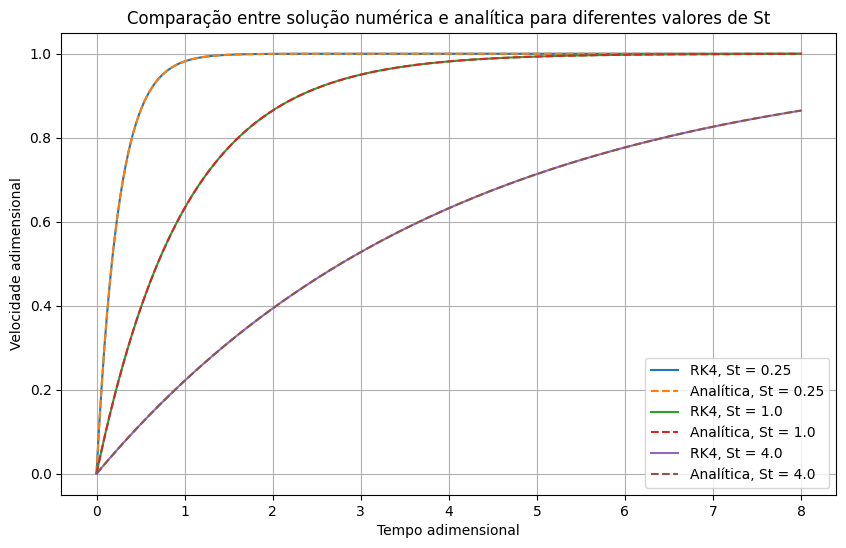

In [2]:
# Comparação entre solução numérica e analítica para diferentes valores de St
Re_s = 0.0
t0 = 0.0
y0 = 0.0
t_final = 8.0
h = 0.01
valores_St = [0.25, 1.0, 4.0]

print(f"{'St':>10} {'erro máximo':>20} {'MSE':>20}")

plt.figure(figsize=(10, 6))

for St in valores_St:
    tempos_num, vel_num = rk4(t=t0, y=y0, h=h, t_final=t_final, St=St, Re_s=Re_s)
    vel_exata = [solucao_analitica_re_zero(t, St, y0) for t in tempos_num]

    erro_max = erro_maximo(tempos_num, vel_num, solucao_analitica_re_zero, St)
    erro_mse = mse(vel_num, vel_exata)

    print(f"{St:>10.2f} {erro_max:>20.10e} {erro_mse:>20.10e}")

    plt.plot(tempos_num, vel_num, label=f"RK4, St = {St}")
    plt.plot(tempos_num, vel_exata, "--", label=f"Analítica, St = {St}")

plt.xlabel("Tempo adimensional")
plt.ylabel("Velocidade adimensional")
plt.title("Comparação entre solução numérica e analítica para diferentes valores de St")
plt.grid(True)
plt.legend()
plt.show()

# Análise para diferentes valores de $St$

No caso $Re_s \to 0$, a solução numérica ficou em boa concordância com a solução analítica para os valores de $St$ testados. Isso mostra que o método numérico implementado reproduz como esperado o comportamento nesse regime.

Também é possível notar que o valor de $St$ altera o tempo com que a solução se aproxima do regime estacionário. Para valores menores de $St$, a resposta é mais rápida. Para valores maiores, a evolução é mais lenta.

Assim, os resultados confirmam que a implementação que a implementação está consistente no caso assintótico.

# Questão 2 - Analisar como a variação do passo temporal $h$ afeta a qualidade da solução numérica no caso $Re_s \to 0$.

         h          erro máximo                  MSE   erro em y(t_final)
   2.50000     5.6635250138e-01     1.6397678445e-01     4.1373324441e-01
   1.00000     7.1205588286e-03     1.4993399836e-05     6.7782448529e-04
   0.50000     2.9140301259e-04     2.8370780961e-08     2.6728472295e-05
   0.10000     3.3324105597e-07     4.0120368233e-14     3.0517669503e-08
   0.01000     3.0913049898e-11     3.5068912969e-22     2.8306246236e-12
   0.00100     1.2656542481e-14     5.7763609590e-29     9.9920072216e-16


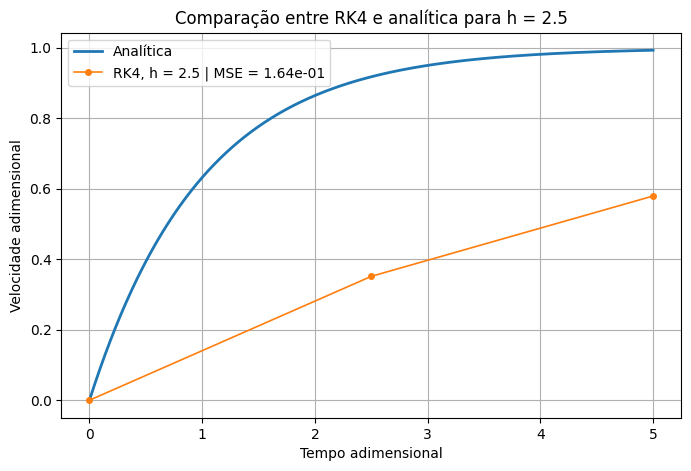

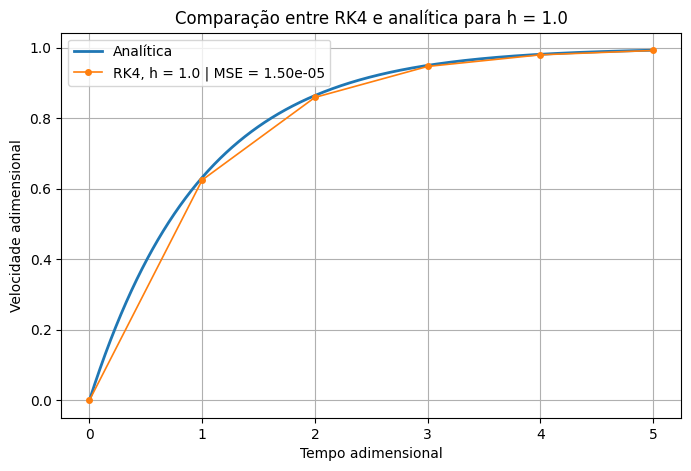

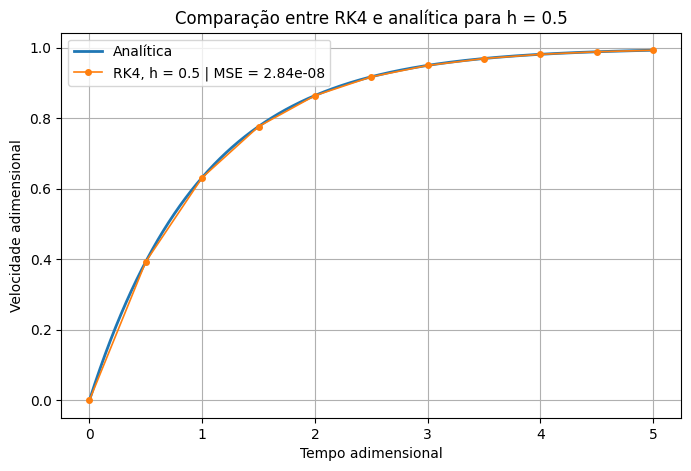

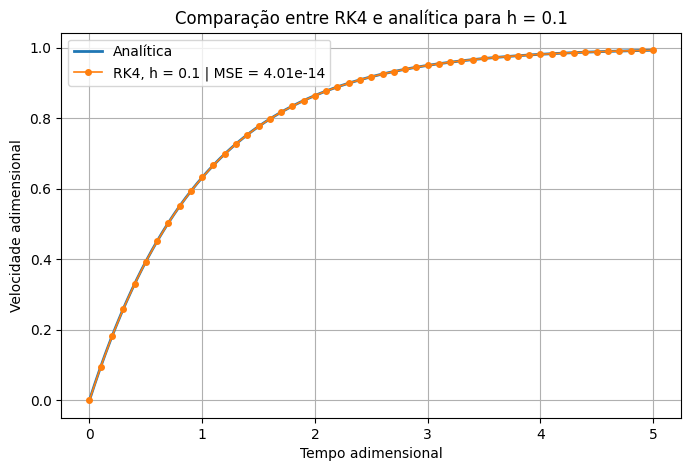

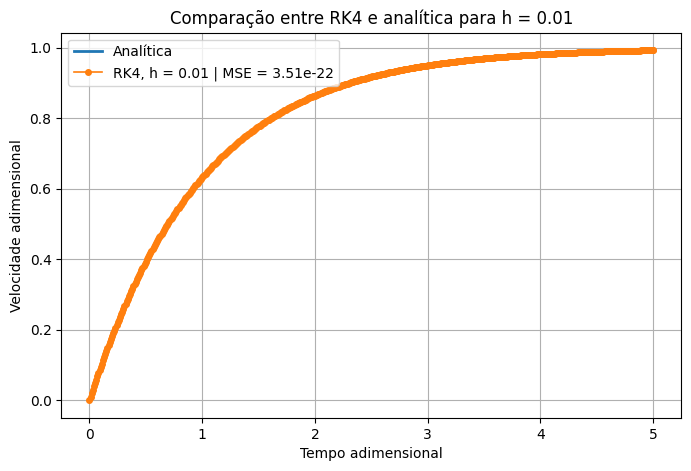

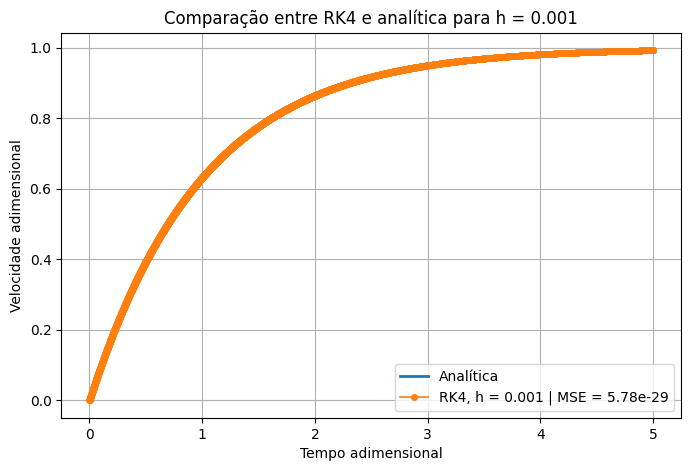

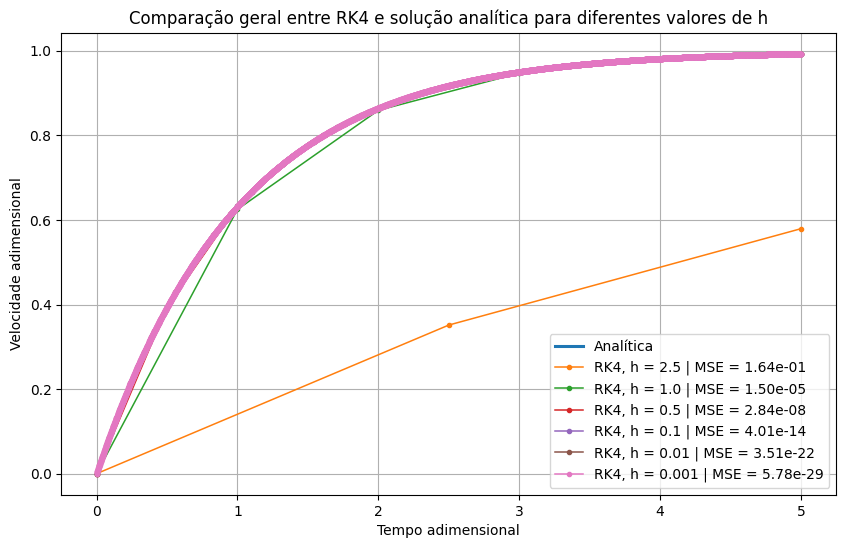

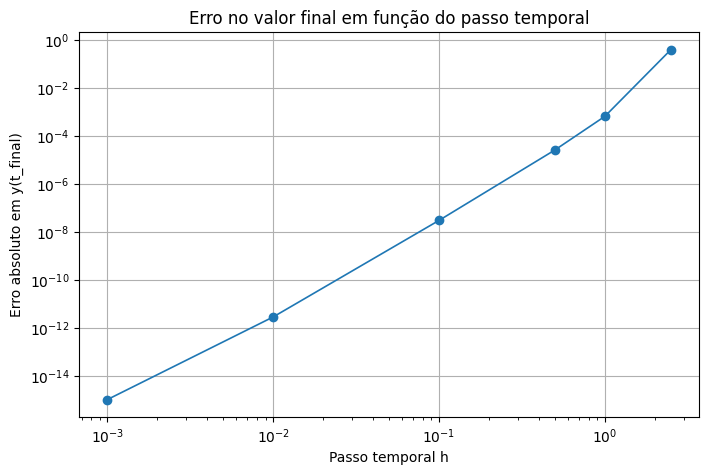

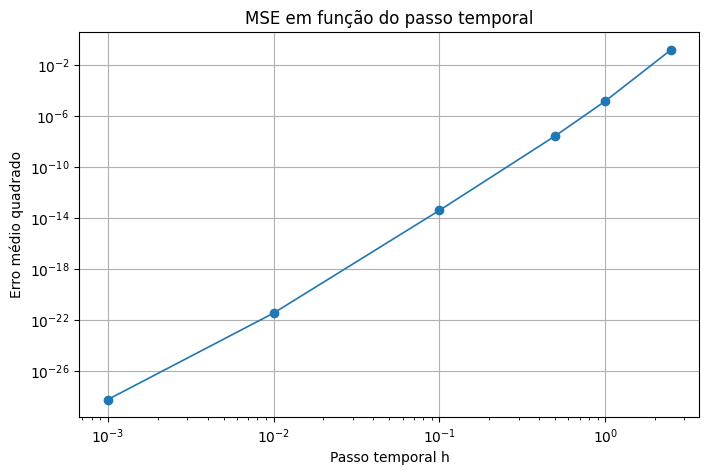

In [6]:
# Influência do passo temporal h
St = 1.0
Re_s = 0.0
t0 = 0.0
y0 = 0.0
t_final = 5.0
h_valores = [2.5, 1.0, 0.5, 0.1, 0.01, 0.001]

tempos_dense = malha_densa(t0, t_final, n_pontos=1500)
vel_analitica_dense = [solucao_analitica_re_zero(t, St, y0) for t in tempos_dense]

lista_h = []
lista_erro_final = []
lista_mse = []
resultados = []

print(f"{'h':>10} {'erro máximo':>20} {'MSE':>20} {'erro em y(t_final)':>20}")

for h in h_valores:
    tempos_num, vel_num = rk4(t=t0, y=y0, h=h, t_final=t_final, St=St, Re_s=Re_s)
    vel_exata_nos_pontos = [solucao_analitica_re_zero(t, St, y0) for t in tempos_num]

    erro_max = erro_maximo(tempos_num, vel_num, solucao_analitica_re_zero, St)
    erro_mse = mse(vel_num, vel_exata_nos_pontos)

    y_final_num = vel_num[-1]
    y_final_exato = solucao_analitica_re_zero(tempos_num[-1], St, y0)
    erro_final = abs(y_final_num - y_final_exato)

    lista_h.append(h)
    lista_erro_final.append(erro_final)
    lista_mse.append(erro_mse)
    resultados.append((h, tempos_num, vel_num, erro_max, erro_mse, erro_final))

    print(f"{h:>10.5f} {erro_max:>20.10e} {erro_mse:>20.10e} {erro_final:>20.10e}")

for h, tempos_num, vel_num, erro_max, erro_mse, erro_final in resultados:
    plt.figure(figsize=(8, 5))
    plt.plot(tempos_dense, vel_analitica_dense, linewidth=2.0, label="Analítica")
    plt.plot(
        tempos_num,
        vel_num,
        marker="o",
        markersize=4,
        linewidth=1.2,
        label=f"RK4, h = {h} | MSE = {erro_mse:.2e}"
    )
    plt.xlabel("Tempo adimensional")
    plt.ylabel("Velocidade adimensional")
    plt.title(f"Comparação entre RK4 e analítica para h = {h}")
    plt.grid(True)
    plt.legend()
    plt.show()

plt.figure(figsize=(10, 6))
plt.plot(tempos_dense, vel_analitica_dense, linewidth=2.2, label="Analítica")

for h, tempos_num, vel_num, erro_max, erro_mse, erro_final in resultados:
    plt.plot(
        tempos_num,
        vel_num,
        marker="o",
        markersize=3,
        linewidth=1.1,
        label=f"RK4, h = {h} | MSE = {erro_mse:.2e}"
    )

plt.xlabel("Tempo adimensional")
plt.ylabel("Velocidade adimensional")
plt.title("Comparação geral entre RK4 e solução analítica para diferentes valores de h")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(lista_h, lista_erro_final, marker="o", linewidth=1.2)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Passo temporal h")
plt.ylabel("Erro absoluto em y(t_final)")
plt.title("Erro no valor final em função do passo temporal")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(lista_h, lista_mse, marker="o", linewidth=1.2)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Passo temporal h")
plt.ylabel("Erro médio quadrado")
plt.title("MSE em função do passo temporal")
plt.grid(True)
plt.show()

## Análise da influência do passo temporal $h$

Os resultados mostram que a redução do passo temporal $h$ melhora a aproximação numérica. Para valores maiores de $h$, os desvios em relação à solução analítica são mais visíveis. Quando $h$ diminui, a solução numérica se aproxima da analítica e os erros também diminuem.

Isso pode ser visto tanto nos gráficos quanto nas métricas calculadas, como o erro máximo, o erro no valor final e o erro médio quadrado. Os gráficos em função de $h$ deixam mais claro esse comportamento.

# Questões 3 e 4

Primeiro, resolve-se numericamente o caso com pequeno efeito inercial. Em seguida, os resultados numéricos são comparados com a solução analítica apresentada no roteiro, para fins de validação.

      Re_s          erro máximo                  MSE           v_terminal
      0.10     3.5808245258e-11     4.5480355092e-22         0.9650737264


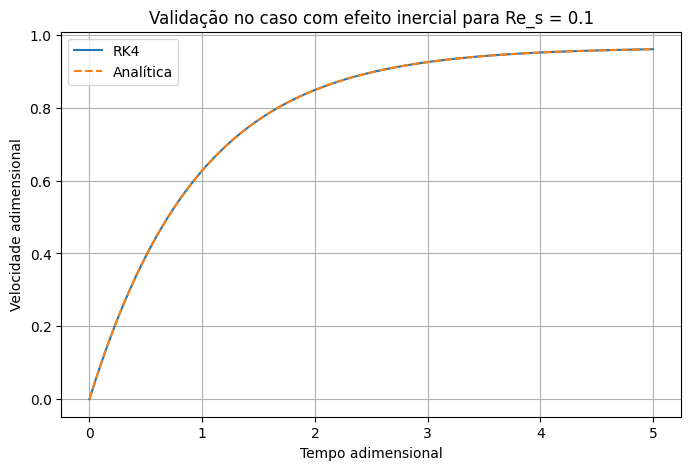

      0.50     5.7751026183e-11     1.0437710512e-21         0.8610017481


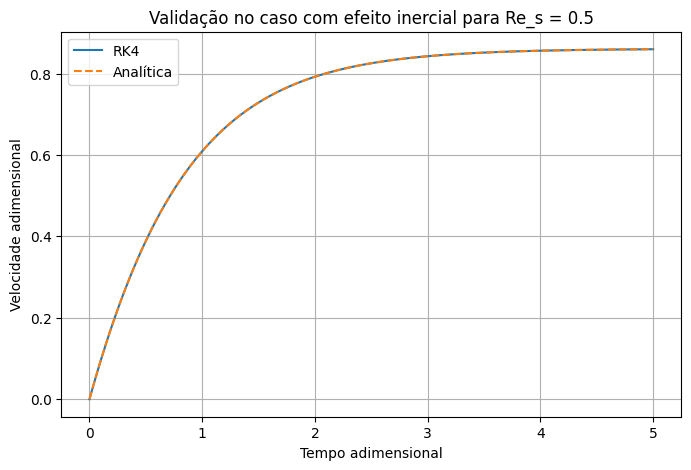

      1.00     8.9895202393e-11     2.2232443034e-21         0.7748517734


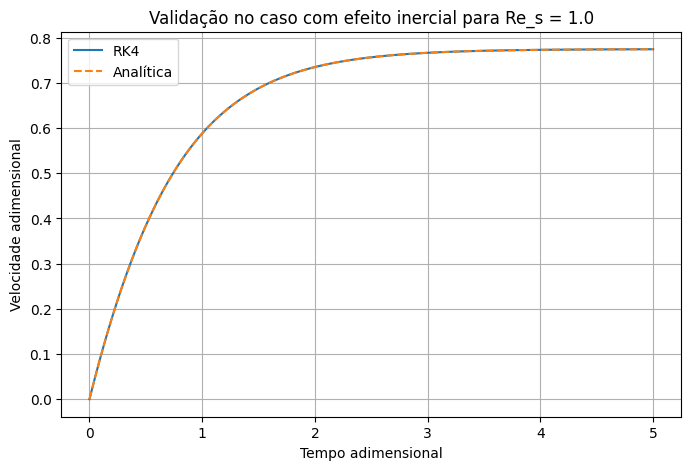

In [4]:
# Validação no caso com pequeno efeito inercial
St = 1.0
t0 = 0.0
y0 = 0.0
t_final = 5.0
h = 0.01
valores_Re_s = [0.1, 0.5, 1.0]

print(f"{'Re_s':>10} {'erro máximo':>20} {'MSE':>20} {'v_terminal':>20}")

for Re_s in valores_Re_s:
    tempos_num, vel_num = rk4(t=t0, y=y0, h=h, t_final=t_final, St=St, Re_s=Re_s)
    vel_exata = [solucao_analitica_caso_inercial(t, St, Re_s, y0) for t in tempos_num]

    erro_max = erro_maximo(tempos_num, vel_num, solucao_analitica_caso_inercial, St, Re_s)
    erro_mse = mse(vel_num, vel_exata)
    v_terminal = velocidade_terminal_caso_inercial(Re_s)

    print(f"{Re_s:>10.2f} {erro_max:>20.10e} {erro_mse:>20.10e} {v_terminal:>20.10f}")

    plt.figure(figsize=(8, 5))
    plt.plot(tempos_num, vel_num, label="RK4")
    plt.plot(tempos_num, vel_exata, "--", label="Analítica")
    plt.xlabel("Tempo adimensional")
    plt.ylabel("Velocidade adimensional")
    plt.title(f"Validação no caso com efeito inercial para Re_s = {Re_s}")
    plt.grid(True)
    plt.legend()
    plt.show()

## Discussão dos resultados das questões 3 e 4

Para o caso com pequeno efeito inercial, a solução numérica também apresentou boa concordância com a solução analítica disponível no roteiro. Isso indica que a implementação do método numérico está correta também para a forma mais geral da equação.

As métricas de erro calculadas reforçam essa conclusão, pois mostram que a diferença entre a solução numérica e a analítica permanece pequena nos casos testados.

Assim, os resultados atendem aos itens 3 e 4 do PPC e mostram que a validação não fica restrita ao caso $Re_s \to 0$.

#Questão 5
Aqui, a solução numérica é obtida para diferentes valores de $Re_s$, com o objetivo de discutir o desvio em relação ao caso assintótico $Re_s \to 0$.

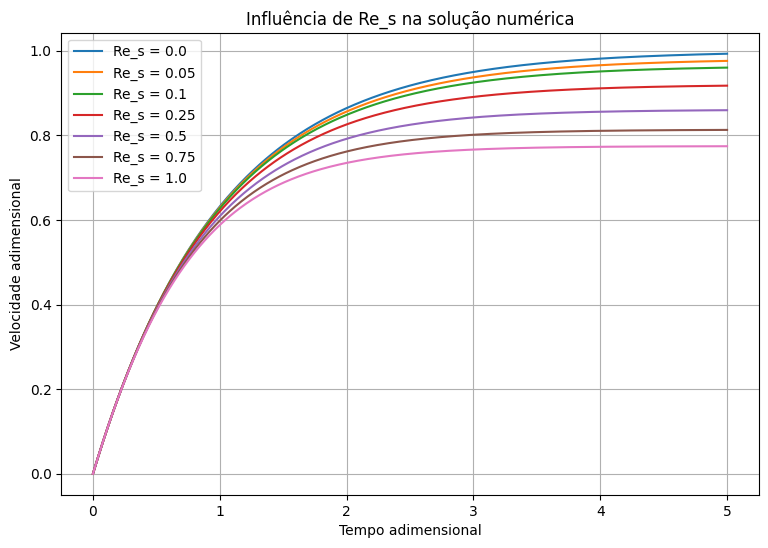

Velocidades terminais adimensionais:
Re_s = 0.00 -> v_terminal = 1.000000
Re_s = 0.05 -> v_terminal = 0.981922
Re_s = 0.10 -> v_terminal = 0.965074
Re_s = 0.25 -> v_terminal = 0.920554
Re_s = 0.50 -> v_terminal = 0.861002
Re_s = 0.75 -> v_terminal = 0.813756
Re_s = 1.00 -> v_terminal = 0.774852


In [5]:
# Efeito de Re_s e desvio em relação ao caso assintótico
St = 1.0
t0 = 0.0
y0 = 0.0
t_final = 5.0
h = 0.01
valores_Re_s = [0.0, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0]

plt.figure(figsize=(9, 6))

for Re_s in valores_Re_s:
    tempos, velocidades = rk4(t=t0, y=y0, h=h, t_final=t_final, St=St, Re_s=Re_s)
    plt.plot(tempos, velocidades, label=f"Re_s = {Re_s}")

plt.xlabel("Tempo adimensional")
plt.ylabel("Velocidade adimensional")
plt.title("Influência de Re_s na solução numérica")
plt.grid(True)
plt.legend()
plt.show()

print("Velocidades terminais adimensionais:")
for Re_s in valores_Re_s:
    print(f"Re_s = {Re_s:.2f} -> v_terminal = {velocidade_terminal_caso_inercial(Re_s):.6f}")

## Discussão do efeito de $Re_s$

Quando $Re_s$ é muito pequeno, a solução fica próxima do caso assintótico $Re_s \to 0$. À medida que $Re_s$ aumenta, o desvio em relação a esse regime também aumenta, pois o termo quadrático passa a ter maior influência na equação.

Além da diferença ao longo do tempo, também se observa alteração no valor terminal da solução, o que mostra que o efeito de $Re_s$ não é apenas transitório.

Assim, os gráficos mostram a mudança de comportamento da solução.

## Conclusões

Os resultados obtidos indicam que o método de Runge-Kutta de 4ª ordem foi implementado corretamente para o problema estudado.

No item 1, houve boa concordância entre a solução numérica e a solução analítica para diferentes valores de $St$ no caso $Re_s \to 0$. No item 2, foi observado que a redução do passo temporal melhora a qualidade da aproximação numérica. Nos itens 3 e 4, o caso com pequeno efeito inercial foi resolvido numericamente e validado com sucesso com base na solução analítica apresentada no roteiro. Por fim, no item 5, a análise para diferentes valores de $Re_s$ mostrou de forma clara o desvio em relação ao caso assintótico.
